In [76]:
# Data Manipulation and Analysis
import pandas as pd 
import numpy as np 

# Data Visualization
import matplotlib.pyplot as plt 
import seaborn as sns 

# Data Preprocessing and Model Building
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.metrics import ConfusionMatrixDisplay


import warnings
warnings.filterwarnings('ignore')


In [17]:
data = pd.read_csv('../data/raw/heart_data_set.csv')
print(f"The shape of the dataset is: {data.shape[0]} rows and {data.shape[1]} columns")
data.head()

The shape of the dataset is: 1025 rows and 14 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [18]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


> **Observations:** 
> 
> All the columns are encoded in int64 except the `oldpeak` which is float64

In [19]:
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [20]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


> **Observations:**
>
> * All variables have **1,025 observations**, indicating there are no missing values.
> * The dataset consists mainly of **middle-aged adults** (median age = 56 years).
> * Approximately **70% of the patients are male**, indicating a gender imbalance.
> * Resting blood pressure and cholesterol show relatively large standard deviations, suggesting substantial variability among patients.
> * The cholesterol feature has a notably high maximum value (564 mg/dL), which may warrant further investigation for outliers during exploratory data analysis.
> * Most binary variables (`sex`, `fbs`, `exang`, and `target`) are encoded as 0 and 1, while features such as `cp`, `restecg`, `slope`, `ca`, and `thal` represent categorical medical measurements encoded numerically.
> * The target classes are **reasonably balanced**, reducing the likelihood that severe class imbalance will negatively affect model training.


# EDA 

## Univariate 

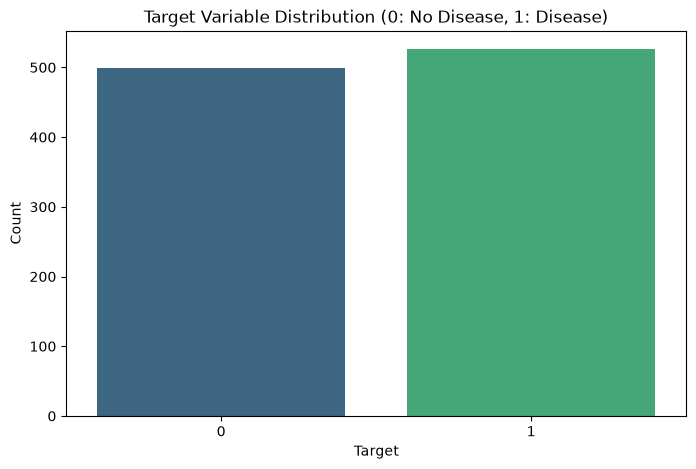

In [22]:
#Target Variable Distribution

plt.figure(figsize=(8, 5))
sns.countplot(x="target", data=data, palette='viridis')
plt.title("Target Variable Distribution (0: No Disease, 1: Disease)")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

> **Observation**
>
> The `target` variable is well balanced, with class labels **0 (no heart disease)** and **1 (heart disease)** representing approximately **48.7%** and **51.3%** of the dataset, respectively. This balanced class distribution is beneficial for training a binary classification model.


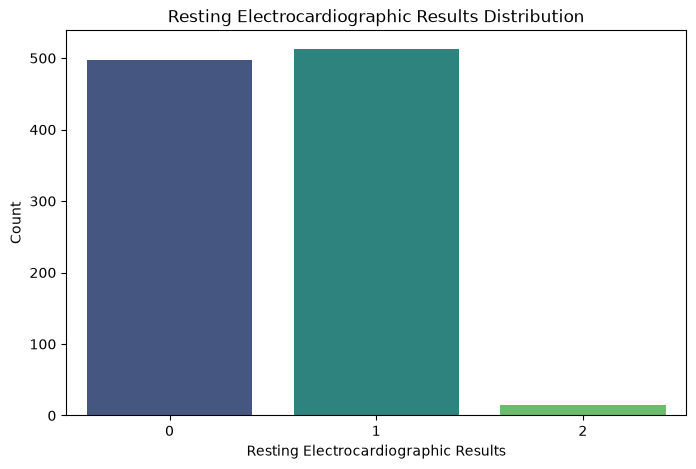

In [ ]:
# Resting Electrocardiographic Results Distribution

plt.figure(figsize=(8, 5))
sns.countplot(x="restecg", data=data, palette='viridis')
plt.title("Resting Electrocardiographic Results Distribution")
plt.xlabel("Resting Electrocardiographic Results")
plt.ylabel("Count")
plt.show()

> **Observation**
>
> The `restecg` feature represents resting electrocardiographic results and contains three categories encoded as **0, 1, and 2**. Category **1** is the most common, appearing in **513 records**, followed closely by category **0** with **497 records**. Category **2** is significantly less frequent, with only **15 records**, indicating a highly imbalanced distribution within this feature. Since category 2 has very few observations, its impact on model training may be limited, and further analysis is required to determine whether it provides meaningful predictive information for heart disease classification.


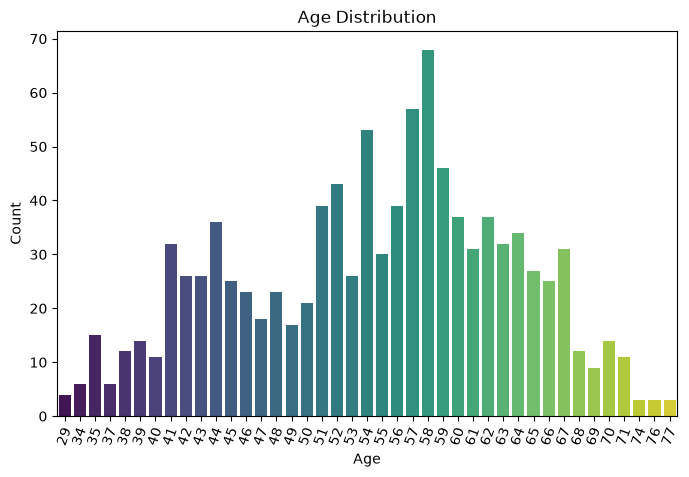

In [ ]:
# Age Distribution

plt.figure(figsize=(8, 5))
sns.countplot(x="age", data=data, palette='viridis')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.xticks(rotation=70)
plt.show()

> **Observation:**
>
> The `age` feature represents the age of patients in the dataset. The patients have an average age of approximately **54 years**, with ages ranging from **29 to 77 years**. The median age is **56 years**, indicating that the dataset primarily consists of middle-aged and older adults. The standard deviation of approximately **9 years** shows a moderate variation in patient ages. The distribution suggests that most patients are concentrated between their late 40s and early 60s, with no extreme age outliers observed.


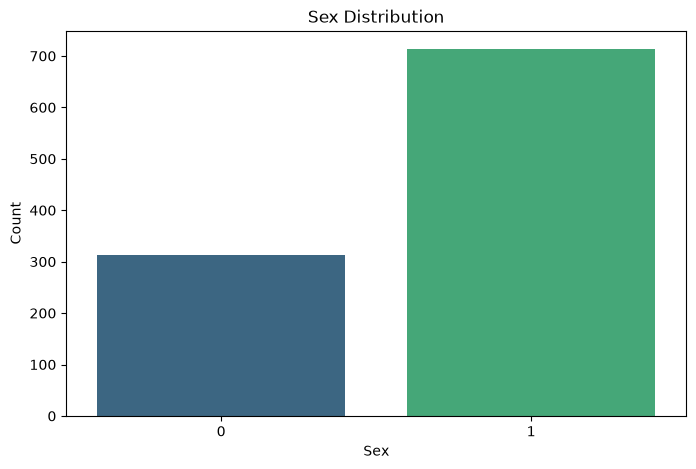

In [34]:
# Sex Distribution

plt.figure(figsize=(8, 5))
sns.countplot(x="sex", data=data, palette='viridis')
plt.title("Sex Distribution")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

> **Observation:**
>
> The `sex` feature contains two categories representing male and female patients. The distribution shows that male patients are more prevalent in the dataset, with approximately **70%** of records belonging to males. This indicates a gender imbalance, although both categories are sufficiently represented for model training.

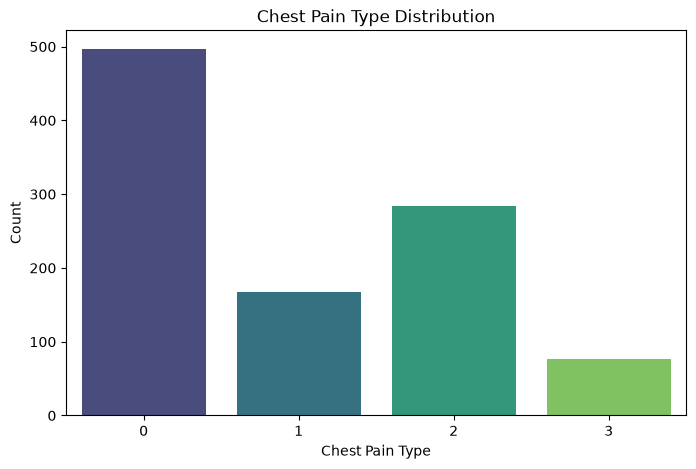

In [39]:
# Chest Pain Type Distribution

plt.figure(figsize=(8, 5))
sns.countplot(x="cp", data=data, palette='viridis')
plt.title("Chest Pain Type Distribution")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.show()

> **Observation:**
>
> The `cp` feature represents different types of chest pain experienced by patients. The distribution shows that chest pain categories are not evenly represented, with some types occurring more frequently than others. This variation indicates that certain chest pain patterns are more common in the dataset and may provide useful information for predicting heart disease.

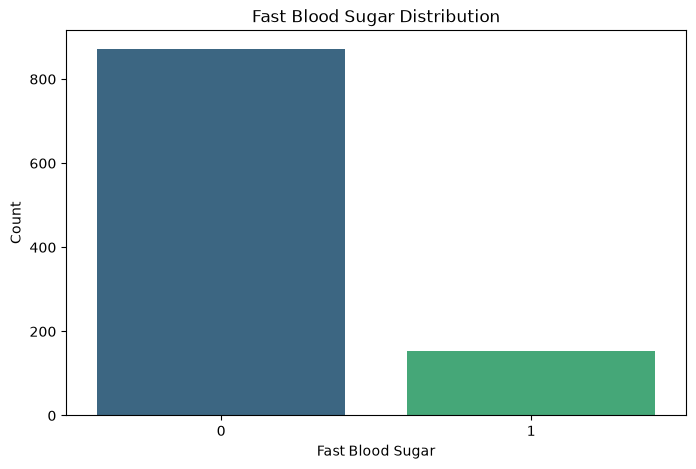

In [40]:
# Fast Blood Sugar Distribution

plt.figure(figsize=(8, 5))
sns.countplot(x="fbs", data=data, palette='viridis')
plt.title("Fast Blood Sugar Distribution")
plt.xlabel("Fast Blood Sugar")
plt.ylabel("Count")
plt.show()

> **Observation:**
> 
> The `fbs` feature indicates whether a patient's fasting blood sugar level is above 120 mg/dl. The majority of patients belong to category 0, suggesting that most individuals in the dataset have fasting blood sugar levels below or equal to 120 mg/dl. Only a smaller proportion belong to category 1, resulting in an imbalanced distribution.

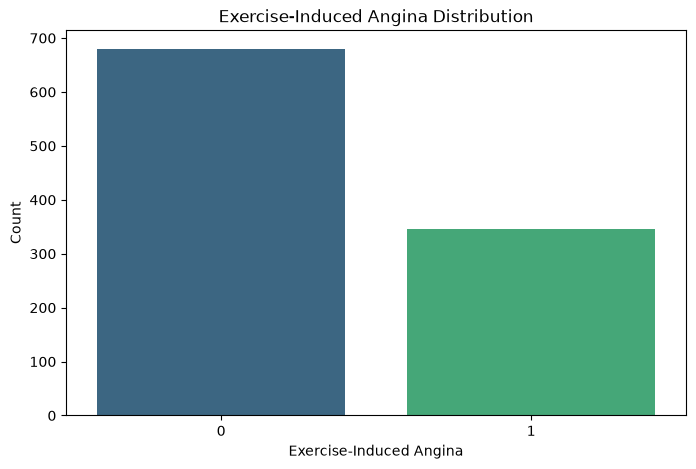

In [41]:
# Exercise-Induced Angina Distribution

plt.figure(figsize=(8, 5))
sns.countplot(x="exang", data=data, palette='viridis')
plt.title("Exercise-Induced Angina Distribution")
plt.xlabel("Exercise-Induced Angina")
plt.ylabel("Count")
plt.show()

> **Observation:**
>
> The `exang` feature represents whether exercise-induced angina is present. The distribution shows that patients without exercise-induced angina are more common than those with the condition. However, both categories contain a reasonable number of samples, allowing the feature to contribute meaningful information during model training.

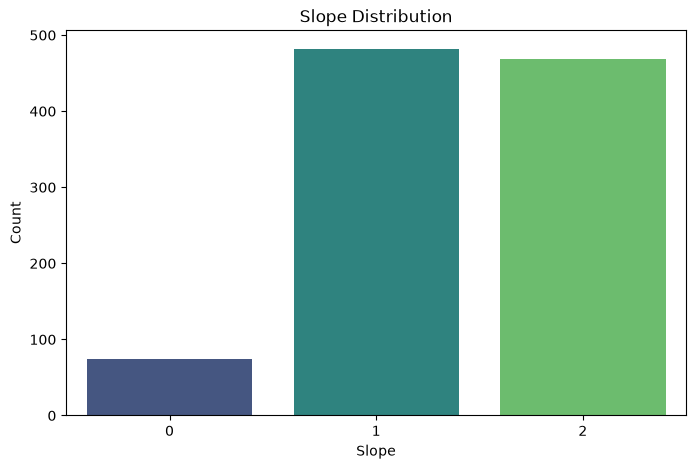

In [42]:
# Slope Distribution

plt.figure(figsize=(8, 5))
sns.countplot(x="slope", data=data, palette='viridis')
plt.title("Slope Distribution")
plt.xlabel("Slope")
plt.ylabel("Count")
plt.show()

> **Observation:**
> 
> The `slope` feature describes the slope of the peak exercise ST segment. The categories are not equally distributed, with one category occurring more frequently than the others. This suggests that certain ST segment patterns are more common among patients in this dataset.

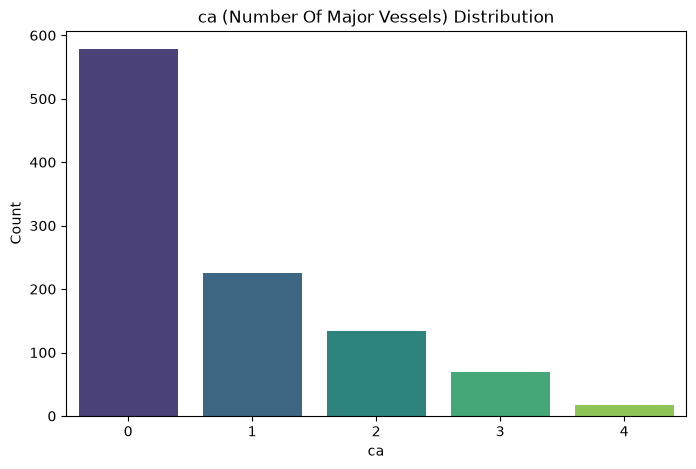

In [44]:
# ca (Number Of Major Vessels) Distribution

plt.figure(figsize=(8, 5))
sns.countplot(x="ca", data=data, palette='viridis')
plt.title("ca (Number Of Major Vessels) Distribution")
plt.xlabel("ca")
plt.ylabel("Count")
plt.show()

> **Observation:**
>
> The `ca` feature represents the number of major vessels colored by fluoroscopy. Most patients have values concentrated around lower categories, particularly category 0, while higher values occur less frequently. The presence of rare categories suggests that this feature may contain important clinical information despite its uneven distribution.

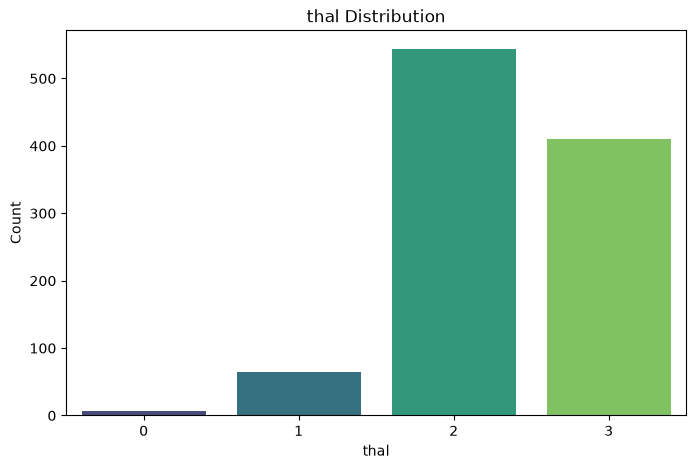

In [45]:
# thal Distribution

plt.figure(figsize=(8, 5))
sns.countplot(x="thal", data=data, palette='viridis')
plt.title("thal Distribution")
plt.xlabel("thal")
plt.ylabel("Count")
plt.show()

> **Observation:**
> 
> The `thal` feature represents thalassemia test results. The distribution shows that categories 2 and 3 are the most common, while some categories have very few observations. The rare categories may require careful interpretation because limited samples can reduce their influence during model trainin

In [47]:
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

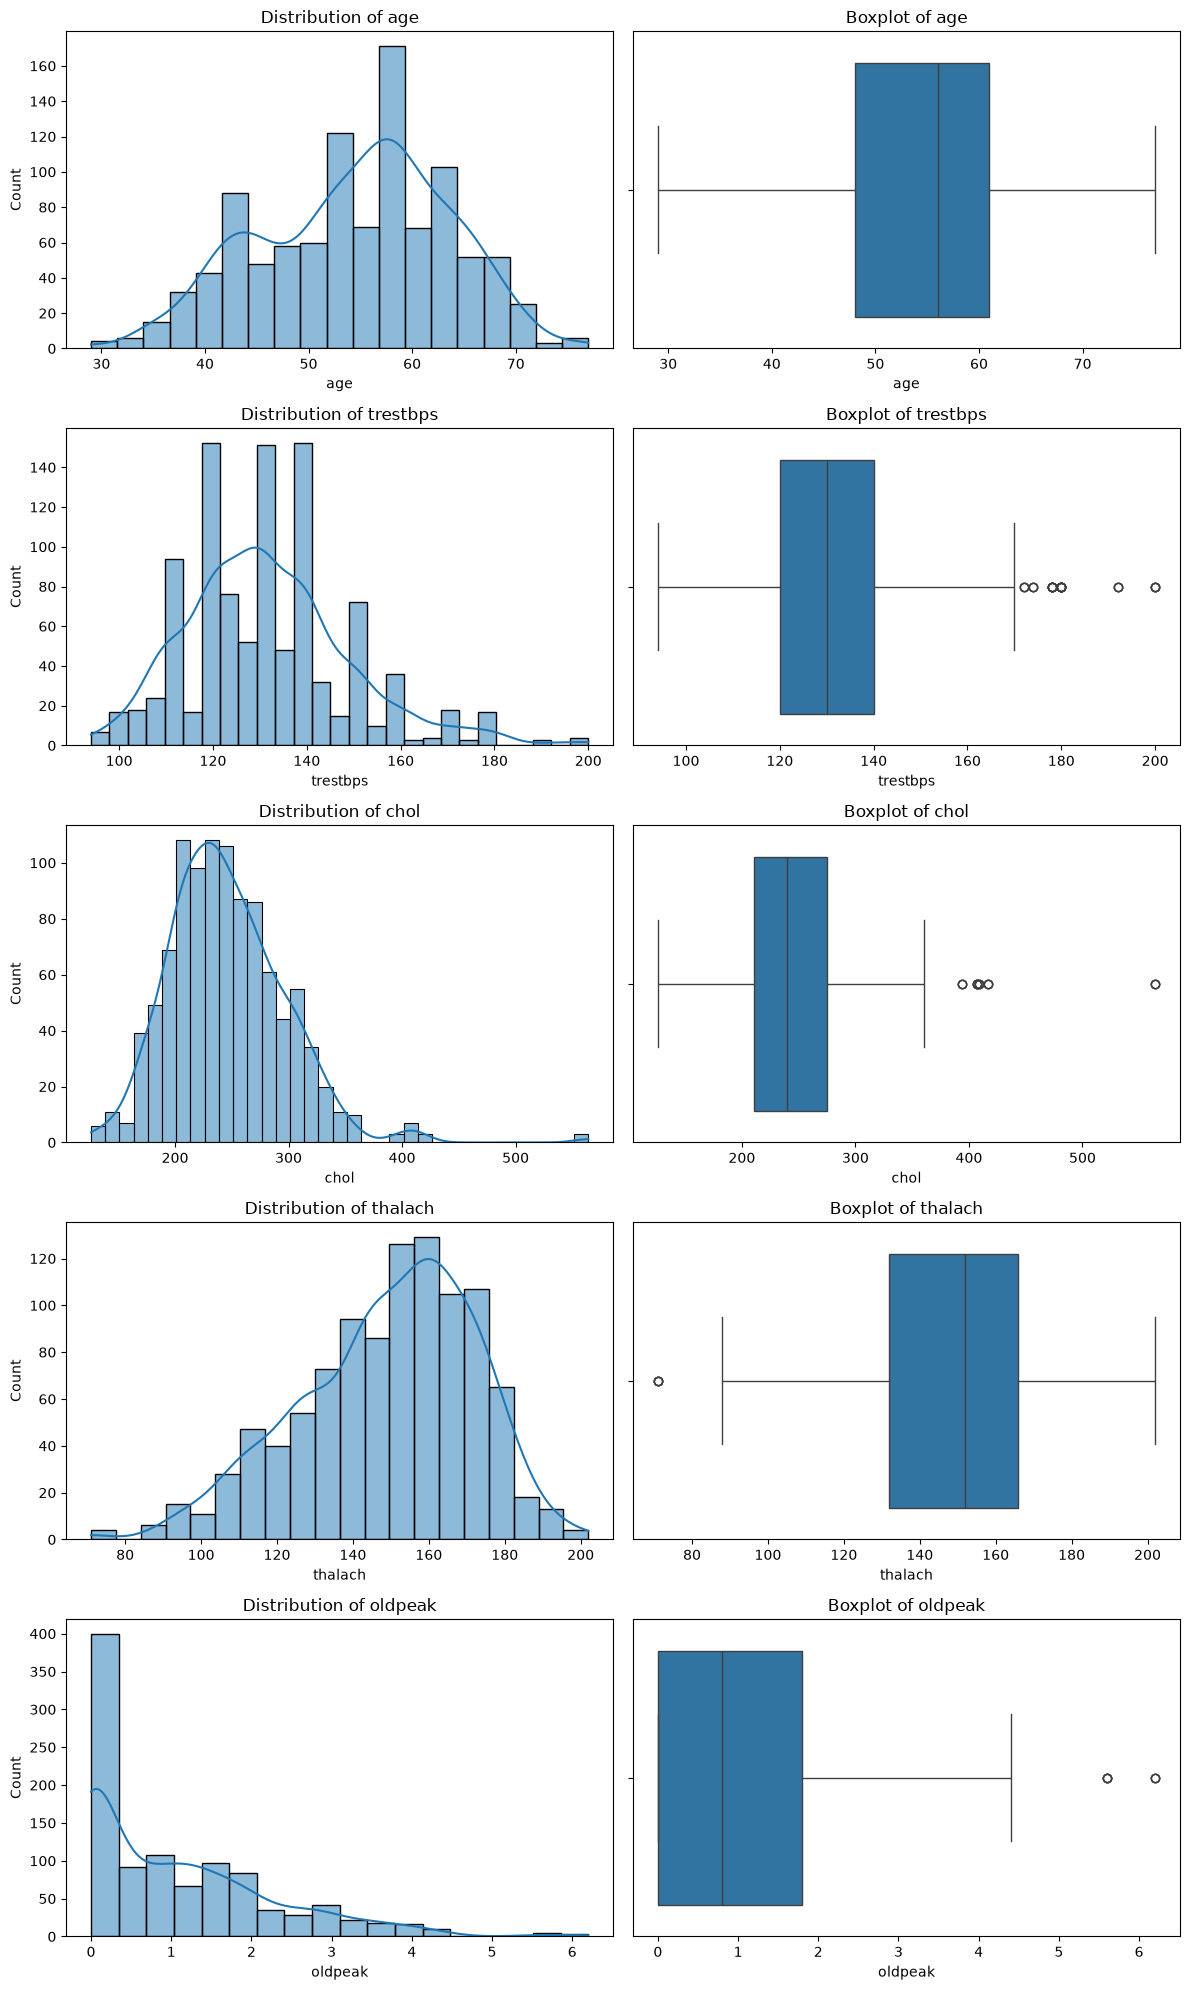

In [ ]:
# Histogram and Boxplot for Numerical Features

fig, axes = plt.subplots(
    nrows=len(numerical_features), 
    ncols=2, 
    figsize=(12, 20)
)

for i, feature in enumerate(numerical_features):

    # Histogram + KDE
    sns.histplot(
        data=data,
        x=feature,
        kde=True,
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f"Distribution of {feature}")

    # Boxplot
    sns.boxplot(
        data=data,
        x=feature,
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f"Boxplot of {feature}")

plt.tight_layout()
plt.show()

> **`Age`**
> 
> **Observations:**
> 
> The `age` distribution shows that patients are mostly middle-aged, with values concentrated around the 50s. The boxplot indicates no significant outliers, suggesting that age values are within a reasonable range.


> **`trestbps` (Resting Blood Pressure)**
>
> **Observations:**
> 
> The `trestbps` feature shows a relatively symmetric distribution, with most patients having resting blood pressure around 120–140 mmHg. The boxplot reveals a few high-value observations that may represent patients with elevated blood pressure.



> **`chol (Cholesterol)`**
> 
> **Observations:**
> 
> The `chol` feature is slightly right-skewed, with most patients having cholesterol values around the normal range. The boxplot highlights several high cholesterol values, indicating possible outliers that may require further investigation.


> **`thalach (Maximum Heart Rate)`**
> 
> **Observations:**
> 
> The `thalach` feature shows an approximately normal distribution, with most patients achieving maximum heart rates around the average range. The boxplot shows limited extreme values, suggesting relatively low variability.


> - **`oldpeak`**
> **Observations:**
> 
> The `oldpeak` feature is positively skewed, with many patients having values close to zero and fewer patients having higher values. The boxplot shows several high-value observations, indicating that some patients experienced greater exercise-induced ST depression.

In [49]:
data[numerical_features].skew()

age        -0.248866
trestbps    0.739768
chol        1.074073
thalach    -0.513777
oldpeak     1.210899
dtype: float64


> **Observation:**
>
> The skewness analysis shows that the numerical features have varying degrees of asymmetry. The `age` feature has a slight negative skewness value (**-0.25**), indicating that the distribution is relatively symmetric with a slightly longer tail toward younger ages. The `thalach` feature also shows a moderate negative skewness (**-0.51**), suggesting that more patients have maximum heart rates above the lower values. In contrast, `trestbps` (**0.74**), `chol` (**1.07**), and `oldpeak` (**1.21**) exhibit positive skewness, indicating right-skewed distributions where a smaller number of patients have higher values. The strong positive skewness in `chol` and `oldpeak` suggests the presence of high-value observations, which aligns with the outliers observed in the boxplots.



## Bivariate

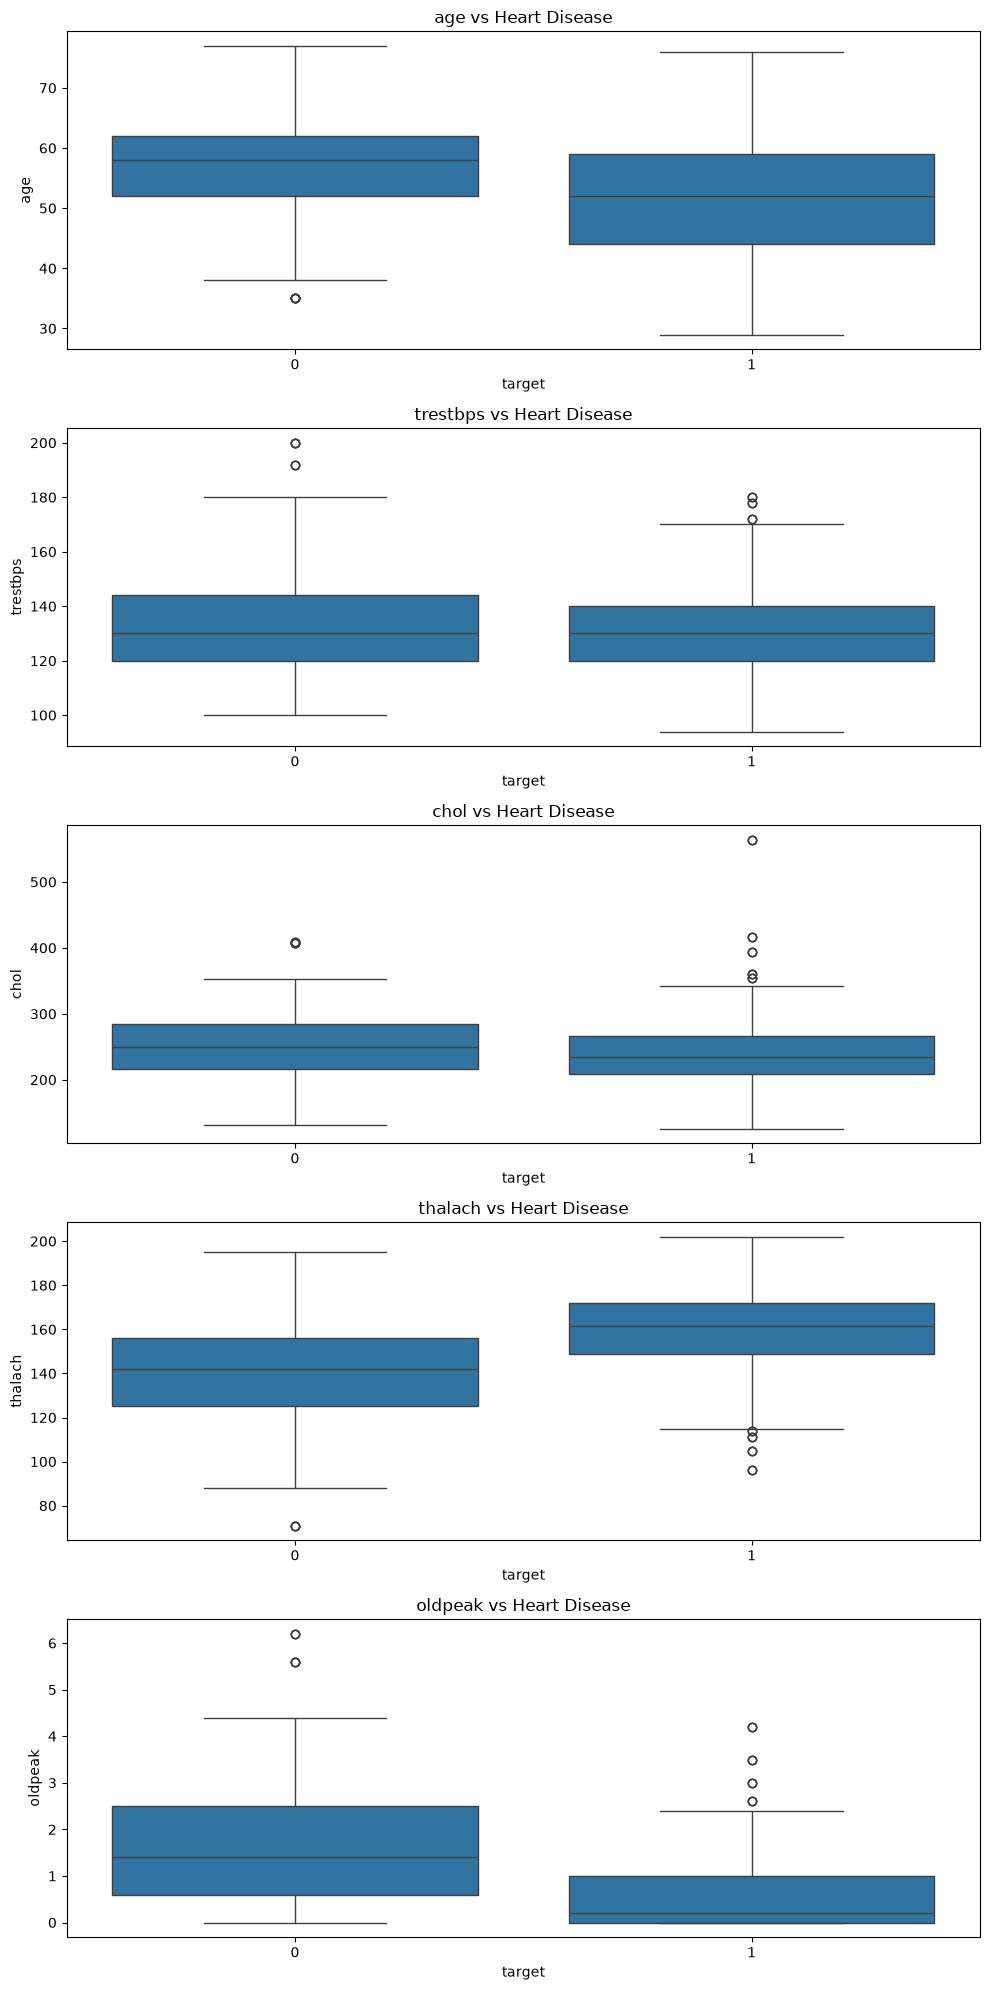

In [ ]:
# Boxplots of Numerical Features vs Target Variable

fig, axes = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(10, 20)
)

for i, feature in enumerate(numerical_features):
    sns.boxplot(
        data=data,
        x="target",
        y=feature,
        ax=axes[i]
    )
    
    axes[i].set_title(f"{feature} vs Heart Disease")

plt.tight_layout()
plt.show()

> **Age**
>
> **Observation:**
>
> The boxplot shows that patients with heart disease tend to have slightly different age distributions compared with those without heart disease. However, there is considerable overlap between the two groups, suggesting that age alone may not be sufficient to distinguish between the classes.


> **Cholesterol**
> 
> **Observation:**
> 
> Cholesterol levels show considerable overlap between patients with and without heart disease. Although some patients with heart disease have higher cholesterol values, the difference between the groups is not very distinct, indicating that cholesterol alone may have limited predictive power.

> **Maximum Heart Rate (thalach)**
>
> **Observation:**
>
> The distribution of maximum heart rate differs between the two groups. Patients without heart disease generally show higher maximum heart rates compared with patients diagnosed with heart disease, suggesting that this feature may provide useful predictive information.

> **Oldpeak**
>
> **Observation:**
>
> Patients with heart disease tend to have higher oldpeak values compared with those without heart disease. This suggests that exercise-induced ST depression may be an important indicator associated with heart disease.

In [52]:
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

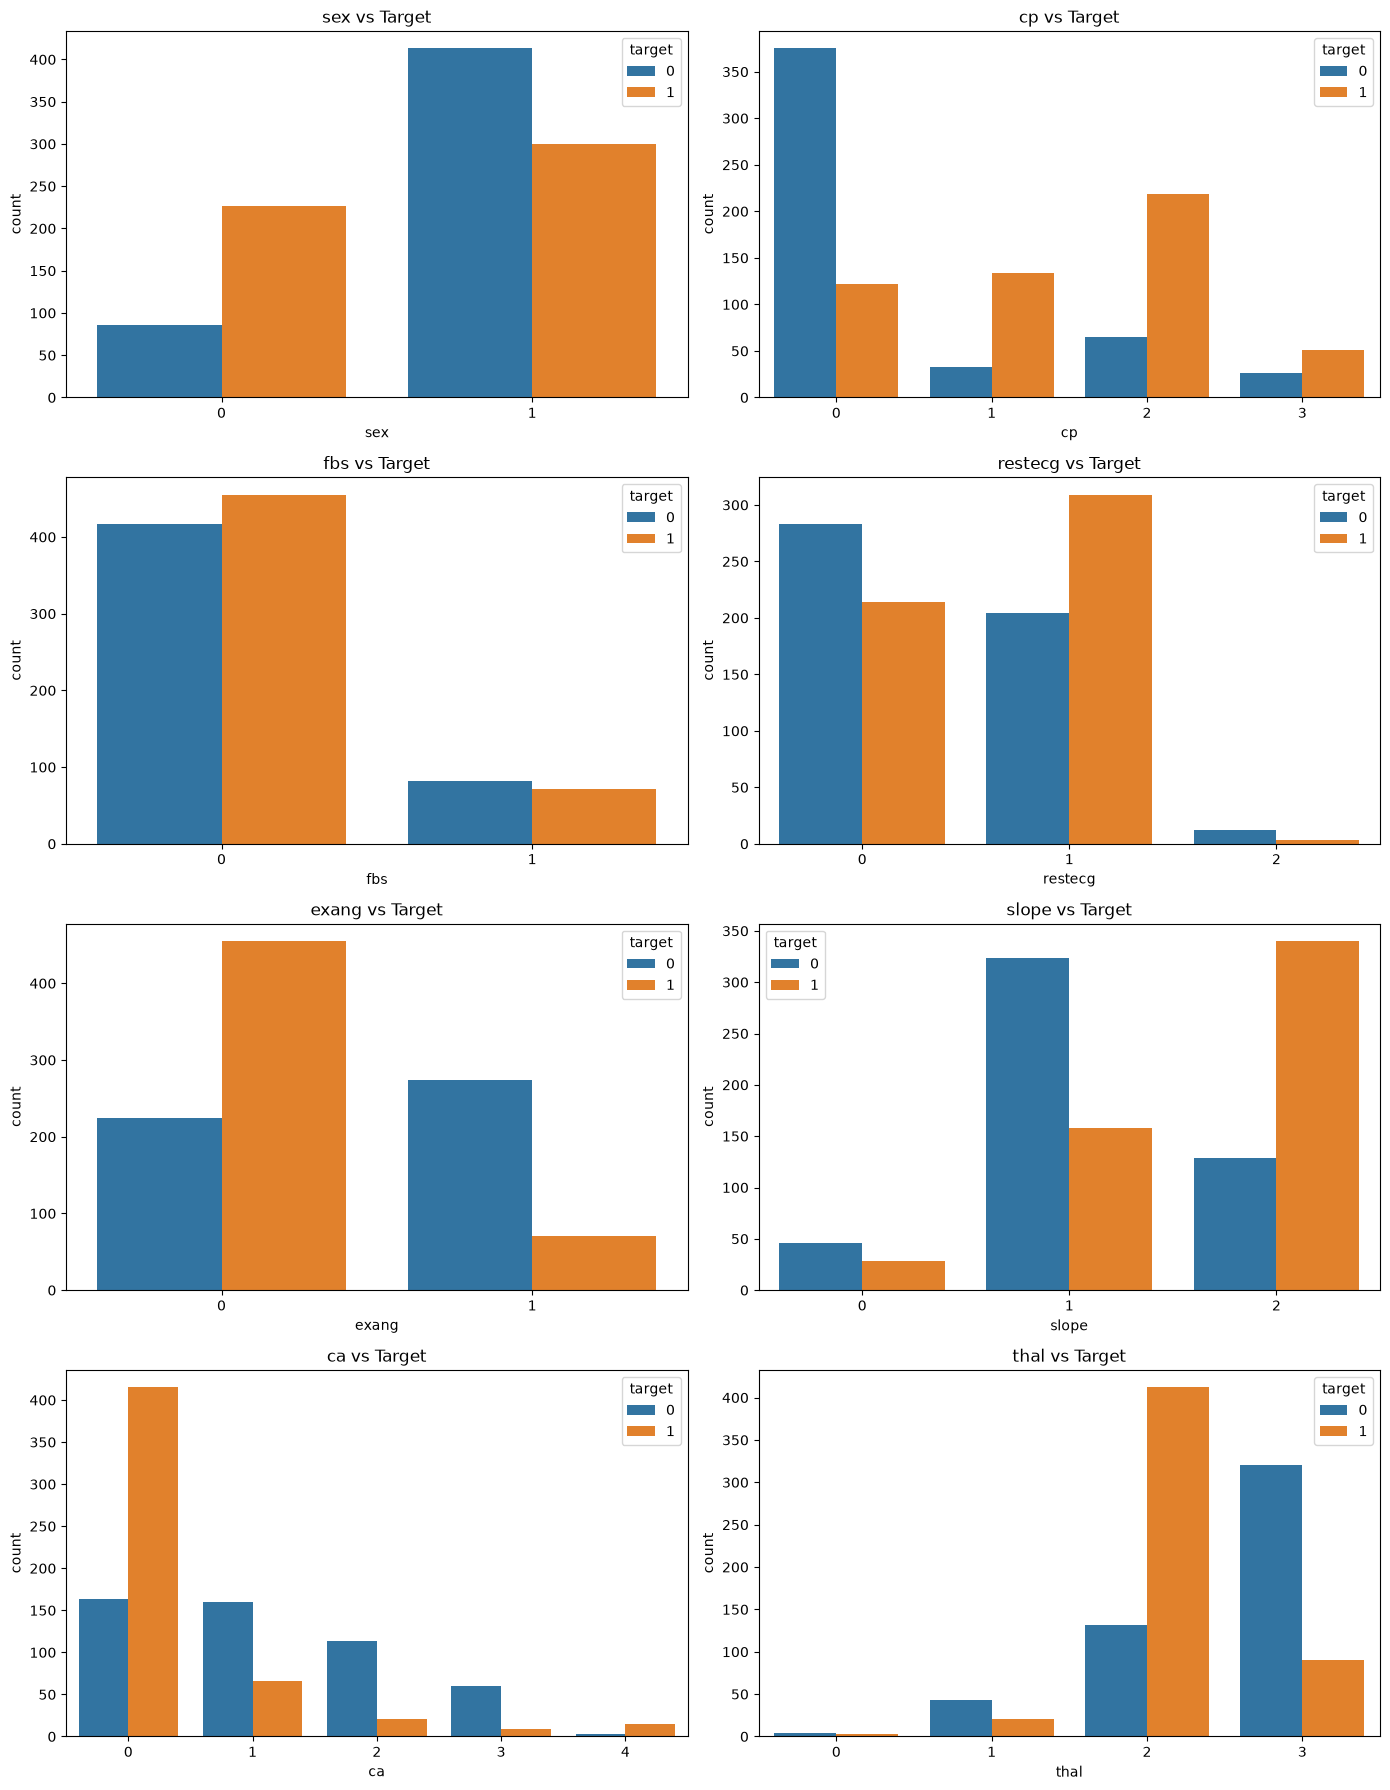

In [55]:
# Countplots of Categorical Features vs Target Variable

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(14, 18)
)

axes = axes.flatten()

for i, feature in enumerate(categorical_features):

    sns.countplot(
        data=data,
        x=feature,
        hue="target",
        ax=axes[i]
    )

    axes[i].set_title(f"{feature} vs Target")

plt.tight_layout()
plt.show()

> **Chest Pain Type (cp)**
>
> **Observation:**
>
> Chest pain type shows differences between patients with and without heart disease. Certain chest pain categories occur more frequently among patients diagnosed with heart disease, indicating that chest pain characteristics may provide useful information for classification.


> **Exercise Angina (exang)**
>
> **Observation:**
>
> Patients with exercise-induced angina show a higher proportion of heart disease cases compared with those without exercise-induced angina. This suggests that exercise-related symptoms are associated with increased likelihood of heart disease.



> **Thal (thal)**
>
> **Observation:**
>
> The distribution of heart disease cases varies across `thal` categories. Some categories show a higher concentration of positive cases, suggesting that `thal` test results may contribute useful predictive information.

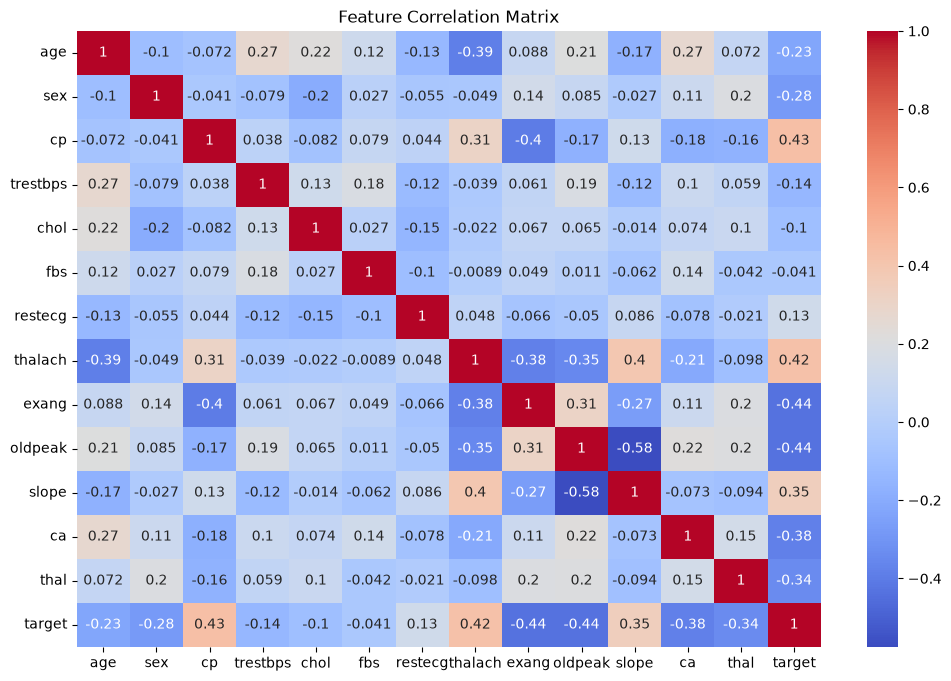

In [56]:
plt.figure(figsize=(12,8))

sns.heatmap(
    data.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")
plt.show()

> **Observation:**
>
> The correlation analysis reveals that `cp`, `thalach`, `exang`, `oldpeak`, `slope`, and `ca` have the strongest relationships with the target variable. `cp` and `thalach` show positive correlations, while `exang`, `oldpeak`, and `ca` show negative correlations. Features such as `chol`, `fbs`, and `restecg` have weak correlations with the target. Although correlation provides useful insights, weakly correlated features may still contribute to a Random Forest model because it can learn complex non-linear patterns.



## Multivariate

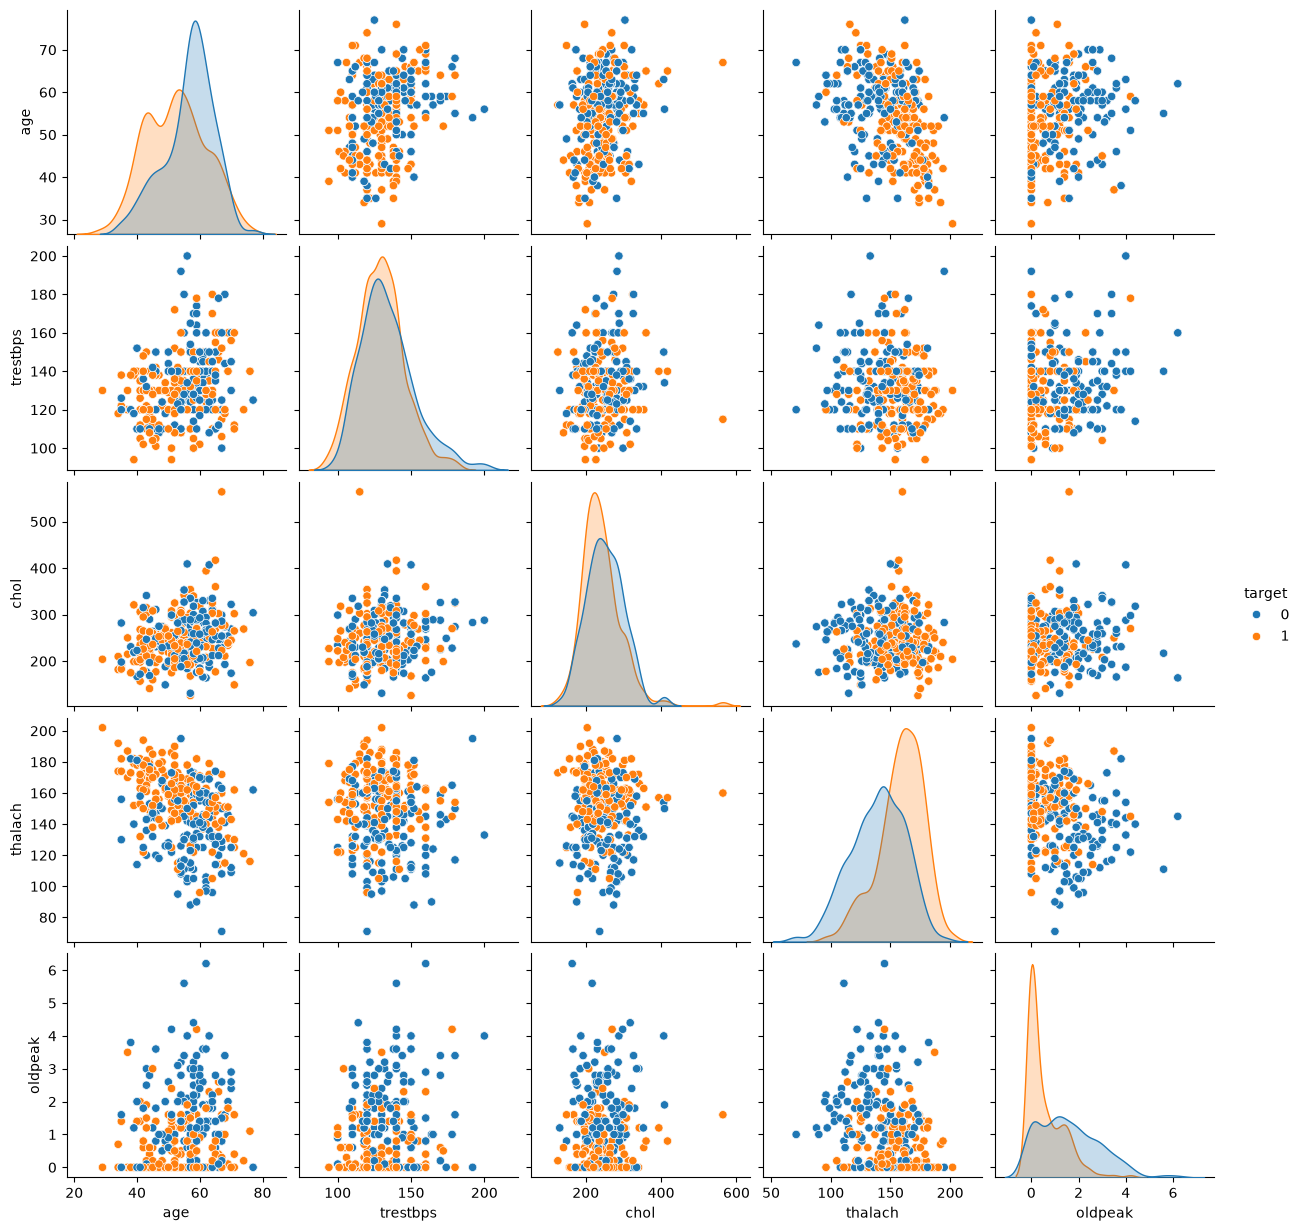

In [ ]:
features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "target"
]


# Pairplot of Features Colored by Target Variable
sns.pairplot(
    data[features],
    hue="target",
    diag_kind="kde"
)

plt.show()

> **Observation:**
>
> The pairplot shows the distribution and relationships between numerical features while distinguishing patients with and without heart disease. Some separation between the target classes can be observed, particularly for features such as `thalach` and `oldpeak`, where the distributions differ between the two groups. However, significant overlap exists, suggesting that multiple features must be considered together for accurate classification.

In [59]:
data.groupby("target")[[
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]].mean()

,age,trestbps,chol,thalach,oldpeak
target,,,,,
0,56.569138,134.106212,251.292585,139.130261,1.600200
1,52.408745,129.245247,240.979087,158.585551,0.569962


> **Observation:**
>
> The grouped analysis shows differences in average clinical measurements between patients with and without heart disease. Patients with heart disease tend to have different maximum heart rate (`thalach`) and exercise-induced ST depression (`oldpeak`) values compared with patients without heart disease. These differences suggest that combinations of clinical measurements may provide useful information for classification.

In [60]:
pd.crosstab(
    [data["sex"], data["cp"]],
    data["target"]
)

target    0    1
sex cp          
0   0    75   58
    1     7   50
    2     4  105
    3     0   13
1   0   300   64
    1    26   84
    2    61  114
    3    26   38

> **Observation:**
>
> The interaction between chest pain type and sex shows differences in heart disease occurrence across patient groups. Certain combinations of symptoms appear more frequently among patients with heart disease, suggesting that feature interactions may improve predictive performance.

# Modelling

In [67]:
# Prepare the data for modeling
X = data.drop("target", axis=1)
y = data["target"]
print(f"Features shape: {X.shape}")
print(f"Target Shape: {y.shape}")

Features shape: (1025, 13)
Target Shape: (1025,)


In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Training target distribution:\n{y_train.value_counts()}")

Training set size: 820
Test set size: 205
Training target distribution:
target
1    423
0    397
Name: count, dtype: int64


In [69]:
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

In [71]:
numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("standard_scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

In [72]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            random_state=42
        ))
    ]
)

In [73]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['age','sex','cp',...,'slope','ca','thal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwe

In [74]:
y_pred = model.predict(X_test)

In [75]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print(
    classification_report(
        y_test,
        y_pred
    )
)

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

Accuracy: 0.9853658536585366
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205

[[102   0]
 [  3 100]]


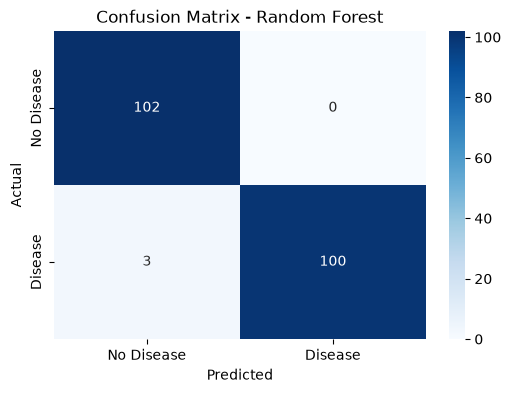

In [78]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

In [80]:
import joblib

joblib.dump(model, "../models/heart_disease_rf.pkl")

['../models/heart_disease_rf.pkl']